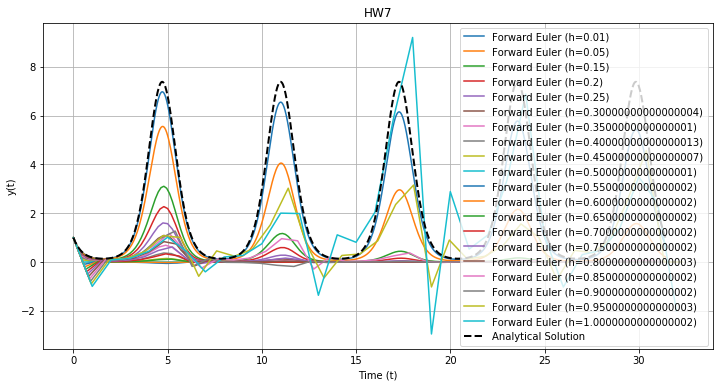

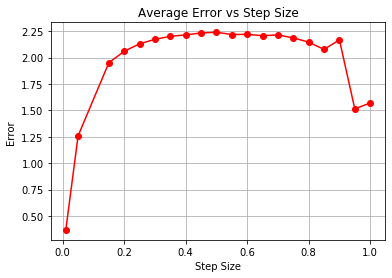

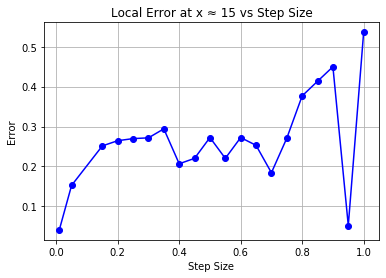

In [3]:
#used my code for ch19 as a starting point
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return -2*y*np.cos(t)


def analytical_solution(t):
    return np.exp(-2 * np.sin(t))

def forward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0
    
    for i in range(1, len(t_values)):
        y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])
        
    return t_values, y_values

y0 = 1
t0 = 0
tf = 10 * np.pi
h_values = [0.01, 0.05] + list(np.arange(0.15, 1.01, 0.05))

plt.figure(figsize=(12, 6))

avg_errors = []
local_errors = []
for h in h_values:
    t_fe, y_fe = forward_euler(f, y0, t0, tf, h)
    plt.plot(t_fe, y_fe, label=f'Forward Euler (h={h})')
    y_exact = analytical_solution(t_fe)
    errors = np.abs(y_fe - y_exact)
    avg_errors.append(np.mean(errors))
    idx = np.argmin(np.abs(t_fe - 15))
    local_errors.append(errors[idx])
t_exact = np.linspace(t0, tf, 1000)
plt.plot(t_exact, analytical_solution(t_exact), 'k--', label='Analytical Solution', linewidth=2)

plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title("HW7")
plt.legend()
plt.grid(True)
plt.show()


plt.figure()
plt.plot(h_values, avg_errors, 'ro-', label='Avg Error')
plt.xlabel('Step Size')
plt.ylabel('Error ')
plt.title('Average Error vs Step Size')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(h_values, local_errors, 'bo-', label='Local Error at x≈15')
plt.xlabel('Step Size')
plt.ylabel('Error')
plt.title('Local Error at x ≈ 15 vs Step Size')
plt.grid(True)
plt.show()

In [2]:
'''
We can see that as h increases, both local and average error increase. This is because of the fact that it is stable when h is less then 1, which we get from the h has to be less than or equal to 2/abs(lambda). Therefore h=1 is our stability limit. 
'''

'\nWe can see that as h increases, both local and average error increase. This is because of the fact that it is stable when h is less then 1, which we get from the h has to be less than or equal to 2/abs(lambda). Therefore h=1 is our stability limit. \n'